In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
from QRT_comp.phase2_qrt_challenge.scripts.utils import backtest_portfolio
import pandas as pd


In [2]:
# Load the downloaded Yahoo Finance data
print('Loading top_5000_yf_data.pkl...')
df_historical = pd.read_pickle('../top_5000_yf_data.pkl')
print('Data loaded successfully.')

Loading top_5000_yf_data.pkl...
Data loaded successfully.


In [3]:
# 1. Calculate Average Daily Volume (ADV) for trailing 60 days\n,
df_daily_volume = df_historical['Close'].mul(df_historical['Volume']).fillna(0)
df_adv_60 = df_daily_volume.rolling(window=60, min_periods=60).mean()

Universe shape: (4117, 5002)


<Axes: title={'center': 'Number of Tradable Stocks Over Time'}, xlabel='Date'>

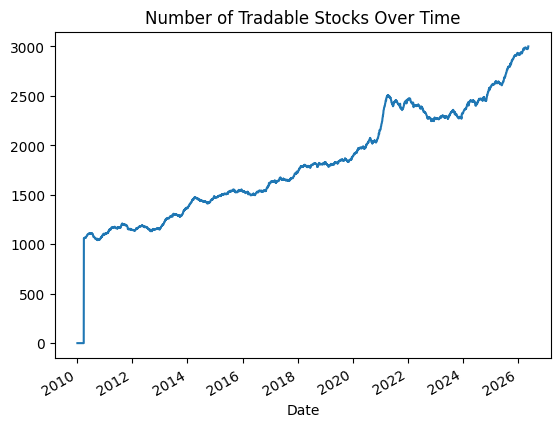

In [4]:
# Creating Universe based on all constraints
df_universe_5m = ((df_adv_60 >= 5_000_000)).astype(int)
print('Universe shape:', df_universe_5m.shape)

df_universe_5m.sum(axis=1).plot(title="Number of Tradable Stocks Over Time")


In [5]:
# Saving 5M universe to stores folder
# Drop any duplicated columns
df_universe_5m = df_universe_5m.loc[:, ~df_universe_5m.columns.duplicated()]


In [6]:
# Calculating returns for each ticker every day
# Using Adj Close to account for dividends and stock splits
returns = df_historical['Adj Close'].pct_change(fill_method=None).fillna(0)

In [7]:
# Saving returns to parquet file
# Drop any duplicated columns
returns = returns.loc[:, ~returns.columns.duplicated()]

In [8]:
import numpy as np

# ==========================================
# Phase 2: 12-Month Momentum Signal
# ==========================================
print('Calculating 252-day momentum signal...')

# 12 months is roughly 252 trading days. We use Adj Close to calculate the true total return.
# 252-day Log Return
df_returns_252 = np.log(df_historical['Adj Close'] / df_historical['Adj Close'].shift(252))
df_signal = np.sign(df_returns_252)

# Generate the directional signal: +1 for positive momentum, -1 for negative.
# If the return is exactly 0 or NaN, np.sign returns 0.
df_signal = np.sign(df_returns_252)

# Mask the signal with our 5M ADV universe. 
# If a stock doesn't meet the liquidity constraint, its signal becomes 0.
df_tradable_signal = df_signal * df_universe_5m


# ==========================================
# Phase 3: Garman-Klass Volatility Engine
# ==========================================
print('Calculating Garman-Klass EWMA Volatility...')

# Note: Yahoo Finance adjusts Open, High, Low, Close for splits historically.
# Because GK uses ratios (High/Low and Close/Open) occurring on the same day, 
# it naturally sidesteps most overnight dividend drop issues.

# 1. Calculate Daily Garman-Klass Variance
# Formula: 0.5 * [ln(H/L)]^2 - (2*ln(2) - 1) * [ln(C/O)]^2
log_hl = np.log(df_historical['High'] / df_historical['Low']) ** 2
log_co = np.log(df_historical['Close'] / df_historical['Open']) ** 2
gk_daily_var = 0.5 * log_hl - ((2 * np.log(2) - 1) * log_co)

# 2. Apply Exponential Smoothing (EWMA)
# The paper specifies a decay factor ensuring a "center of mass" of 60 days.
# Pandas' ewm(com=60) directly applies this mathematical definition.
gk_ewma_var = gk_daily_var.ewm(com=60, min_periods=60).mean()

# 3. Annualize the variance and convert to volatility (Standard Deviation)
# Multiply by 252 (trading days) to annualize, then take the square root.
df_annualized_vol = np.sqrt(gk_ewma_var * 252)

# 4. Apply the Volatility Floor
# We hardcode a minimum volatility of 15% (0.15) to prevent inverse-volatility 
# position sizes from exploding to infinity during artificially quiet periods.
df_vol_floored = df_annualized_vol.clip(lower=0.15)


# ==========================================
# Phase 4: Unconstrained Position Sizing
# ==========================================
print('Calculating inverse-volatility position weights...')

TARGET_VOL = 0.40 # Target 40% annualized volatility per position, as per the paper

# Weight = Signal * (Target Volatility / Asset Volatility)
df_unconstrained_weights = df_tradable_signal * (TARGET_VOL / df_vol_floored)

print('Signal and Volatility pipelines complete.')

Calculating 252-day momentum signal...


c:\Users\USER\Documents\GitHub\QRT_comp\.venv\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


Calculating Garman-Klass EWMA Volatility...
Calculating inverse-volatility position weights...
Signal and Volatility pipelines complete.


In [9]:
import pandas as pd
import numpy as np

# ==========================================
# Phase 4: Institutional Portfolio Construction
# ==========================================
print('Constructing institutional portfolio...')

# 1. Align unconstrained weights with the current universe 
raw_weights = df_unconstrained_weights * df_universe_5m

# 2. Monthly Resampling
monthly_target_weights = raw_weights.resample('BME').last()

# 3. Enforce the Unit Capital Constraint (GMV = 1)
gmv_monthly = monthly_target_weights.abs().sum(axis=1) + 1e-10
portfolio_monthly = monthly_target_weights.div(gmv_monthly, axis=0)

# 4. Enforce the Max Weight Constraint (10%)
portfolio_monthly = portfolio_monthly.clip(lower=-0.1, upper=0.1)

# Re-normalize after clipping
gmv_clipped = portfolio_monthly.abs().sum(axis=1) + 1e-10
portfolio_monthly = portfolio_monthly.div(gmv_clipped, axis=0)

# 5. Expand back to Daily Frequency, Align Shapes, and SHIFT
portfolio_daily = portfolio_monthly.reindex(returns.index).ffill()
portfolio_shifted = portfolio_daily.shift(1)

# ---> THE FIX: Drop duplicated columns from both the source and the target <---
portfolio_shifted = portfolio_shifted.loc[:, ~portfolio_shifted.columns.duplicated()]
unique_return_columns = returns.columns[~returns.columns.duplicated()]

# Force exact shape alignment with unique `returns` columns
portfolio_aligned = portfolio_shifted.reindex(columns=unique_return_columns, fill_value=0)

# 6. Apply the Universe Mask
# Make sure universe is also strictly unique for the multiplication
safe_universe = df_universe_5m.loc[:, ~df_universe_5m.columns.duplicated()]
portfolio_masked = portfolio_aligned * safe_universe

# 7. Final Daily Re-normalization
daily_gmv = portfolio_masked.abs().sum(axis=1) + 1e-10
portfolio_final = portfolio_masked.div(daily_gmv, axis=0)

# Clean up any NaNs created by shifting or dividing by zero
portfolio_final = portfolio_final.fillna(0)

print(f'Shape Check - Returns: {returns.loc[:, ~returns.columns.duplicated()].shape}, Universe: {safe_universe.shape}, Portfolio: {portfolio_final.shape}')
print('Portfolio construction complete. Ready for backtest.')

# ==========================================
# Phase 5: Execution
# ==========================================
# Call your backtest function!
# We pass the deduplicated returns and universe to ensure exact alignment
net_sharpe, pnl_series = backtest_portfolio(
    portfolio=portfolio_final, 
    returns=returns.loc[:, ~returns.columns.duplicated()], 
    universe=safe_universe, 
    plot_=True, 
    print_=True
)

Constructing institutional portfolio...
Shape Check - Returns: (4117, 4999), Universe: (4117, 4999), Portfolio: (4117, 4999)
Portfolio construction complete. Ready for backtest.
Gross Sharpe Ratio:  0.341
Net Sharpe Ratio:  0.278
Turnover %:  1.545


In [10]:
import pandas as pd
import numpy as np

def generate_yearly_tearsheet(portfolio, returns):
    print("Generating Yearly Tear Sheet...")
    
    # 1. Recalculate Daily PnL and Costs (matching your backtest logic)
    portfolio = portfolio.fillna(0)
    rets = returns.fillna(0)
    
    gross_pnl = (portfolio * rets).sum(axis=1)
    traded = portfolio.diff(1).abs().sum(axis=1).fillna(0)
    book_value = portfolio.abs().sum(axis=1)
    
    execution_cost = traded * 2e-4
    financing_cost = book_value * (0.005 / 252)
    net_pnl = gross_pnl - execution_cost - financing_cost
    
    # Create a DataFrame to hold daily portfolio data
    df_perf = pd.DataFrame({
        'Gross_PnL': gross_pnl,
        'Net_PnL': net_pnl,
        'Traded': traded,
        'Book_Value': book_value
    })
    
    # Add Year column for grouping
    df_perf['Year'] = df_perf.index.year
    
    # 2. Define metric calculations per year
    yearly_metrics = []
    
    for year, group in df_perf.groupby('Year'):
        # Skip years with less than 50 trading days (e.g., partial first year)
        if len(group) < 50:
            continue
            
        # Returns
        gross_ret = group['Gross_PnL'].sum()
        net_ret = group['Net_PnL'].sum()
        
        # Volatility & Sharpe (Annualized)
        daily_vol = group['Net_PnL'].std()
        ann_vol = daily_vol * np.sqrt(252)
        net_sharpe = (group['Net_PnL'].mean() / daily_vol) * np.sqrt(252) if daily_vol > 0 else 0
        
        # Hit Rate (Percentage of days with strictly positive Net PnL)
        win_days = (group['Net_PnL'] > 0).sum()
        total_days = len(group)
        hit_rate = win_days / total_days
        
        # Max Drawdown
        cum_net = group['Net_PnL'].cumsum()
        running_max = cum_net.cummax()
        drawdown = cum_net - running_max
        max_dd = drawdown.min()
        
        # Annualized Turnover (Daily mean traded / mean book * 252)
        mean_traded = group['Traded'].mean()
        mean_book = group['Book_Value'].mean()
        ann_turnover = (mean_traded / mean_book) * 252 if mean_book > 0 else 0
        
        yearly_metrics.append({
            'Year': year,
            'Net Return (%)': round(net_ret * 100, 2),
            'Gross Return (%)': round(gross_ret * 100, 2),
            'Net Sharpe': round(net_sharpe, 2),
            'Max Drawdown (%)': round(max_dd * 100, 2),
            'Daily Win Rate (%)': round(hit_rate * 100, 2),
            'Ann. Turnover (%)': round(ann_turnover * 100, 2)
        })
    
    # 3. Format and output
    df_tearsheet = pd.DataFrame(yearly_metrics).set_index('Year')
    
    # Calculate Overall Stats to append at the bottom
    overall_net_ret = df_perf['Net_PnL'].sum()
    overall_gross_ret = df_perf['Gross_PnL'].sum()
    overall_vol = df_perf['Net_PnL'].std() * np.sqrt(252)
    overall_sharpe = (df_perf['Net_PnL'].mean() / df_perf['Net_PnL'].std()) * np.sqrt(252)
    
    cum_net_all = df_perf['Net_PnL'].cumsum()
    max_dd_all = (cum_net_all - cum_net_all.cummax()).min()
    overall_win = (df_perf['Net_PnL'] > 0).sum() / len(df_perf)
    overall_turnover = (df_perf['Traded'].mean() / df_perf['Book_Value'].mean()) * 252
    
    print("\n--- YEARLY PERFORMANCE TEAR SHEET ---")
    display(df_tearsheet)
    
    print("\n--- OVERALL METRICS ---")
    print(f"Total Net Return:   {round(overall_net_ret * 100, 2)}%")
    print(f"Total Gross Return: {round(overall_gross_ret * 100, 2)}%")
    print(f"Overall Net Sharpe: {round(overall_sharpe, 2)}")
    print(f"Max Drawdown:       {round(max_dd_all * 100, 2)}%")
    print(f"Daily Win Rate:     {round(overall_win * 100, 2)}%")
    print(f"Ann. Turnover:      {round(overall_turnover * 100, 2)}%")
    
    return df_tearsheet

# Run the analysis
# Make sure to pass the EXACT portfolio and returns DataFrames that you fed to backtest_portfolio
tearsheet_df = generate_yearly_tearsheet(portfolio_final, returns.loc[:, ~returns.columns.duplicated()])

Generating Yearly Tear Sheet...

--- YEARLY PERFORMANCE TEAR SHEET ---


,Net Return (%),Gross Return (%),Net Sharpe,Max Drawdown (%),Daily Win Rate (%),Ann. Turnover (%)
Year,,,,,,
2010,0.00,0.00,0.00,0.00,0.00,0.00
2011,-5.00,-4.46,-0.34,-16.18,47.22,468.11
2012,4.14,4.72,0.90,-3.59,52.40,430.03
2013,23.94,24.49,2.60,-5.75,57.54,253.78
2014,5.49,6.05,0.64,-6.66,58.73,309.48
2015,4.69,5.27,0.81,-4.20,53.97,377.80
2016,-4.37,-3.78,-0.75,-7.98,49.21,411.91
2017,13.78,14.34,2.32,-2.12,57.37,306.90
2018,-0.84,-0.27,-0.12,-5.87,56.18,378.62



--- OVERALL METRICS ---
Total Net Return:   38.81%
Total Gross Return: 47.63%
Overall Net Sharpe: 0.28
Max Drawdown:       -28.35%
Daily Win Rate:     50.57%
Ann. Turnover:      389.37%


In [11]:
import yfinance as yf
import numpy as np
import pandas as pd

print("Fetching SPY data and calculating residual returns...")

# 1. Fetch SPY Data
# Add 1 day to the end to ensure we capture the final date of your dataset
start_date = returns.index.min()
end_date = returns.index.max() + pd.Timedelta(days=1)
spy_df = yf.download('SPY', start=start_date, end=end_date, progress=False)

# --- THE FIX: Robustly extract the adjusted close ---
# If yfinance returned a MultiIndex (e.g., columns are ('Close', 'SPY')), flatten it
if isinstance(spy_df.columns, pd.MultiIndex):
    spy_df.columns = spy_df.columns.droplevel(1)

# If 'Adj Close' exists, use it. Otherwise, 'Close' is already adjusted.
if 'Adj Close' in spy_df.columns:
    spy_adj_close = spy_df['Adj Close'].squeeze()
else:
    spy_adj_close = spy_df['Close'].squeeze()

# Ensure the index is timezone-naive to perfectly match your returns dataframe
if spy_adj_close.index.tz is not None:
    spy_adj_close.index = spy_adj_close.index.tz_localize(None)
# --------------------------------------------------

# 2. Calculate SPY Log Returns and align to our exact trading calendar
spy_log_rets = np.log(spy_adj_close / spy_adj_close.shift(1))
spy_rets_aligned = spy_log_rets.reindex(returns.index).fillna(0)

# 3. Calculate Rolling Beta (Covariance / Variance)
# We use a 252-day window for beta, requiring at least 63 days (3 months) of data to start
ROLLING_WINDOW = 252

print("Calculating rolling market covariances...")
# Variance of SPY
spy_var = spy_rets_aligned.rolling(window=ROLLING_WINDOW, min_periods=63).var()

# Covariance of every stock with SPY
rolling_cov = returns.rolling(window=ROLLING_WINDOW, min_periods=63).cov(spy_rets_aligned)

# Beta = Cov(Asset, Market) / Var(Market)
rolling_beta = rolling_cov.div(spy_var, axis=0)

# If a stock doesn't have enough history for a beta, default to 1.0 (moves 1:1 with market)
rolling_beta = rolling_beta.fillna(1.0)

# 4. Calculate Residual Returns
# We subtract the market component (Beta * SPY Return) from the stock's total return
market_component = rolling_beta.multiply(spy_rets_aligned, axis=0)
residual_returns = returns - market_component

print("Residual returns calculated successfully.")

Fetching SPY data and calculating residual returns...
Calculating rolling market covariances...
Residual returns calculated successfully.


In [12]:
print("Generating 1M/3M/12M Composite Residual Signal...")

# 1. Calculate cumulative residual log returns for each horizon
# We use rolling sums on the daily residual log returns
res_ret_1m = residual_returns.rolling(window=21).sum()
res_ret_3m = residual_returns.rolling(window=63).sum()
res_ret_12m = residual_returns.rolling(window=252).sum()

# 2. Generate directional signs for each timeframe (-1, 0, or 1)
sig_1m = np.sign(res_ret_1m)
sig_3m = np.sign(res_ret_3m)
sig_12m = np.sign(res_ret_12m)

# 3. Blend the signals equally
# This creates our continuous signal (e.g., if 12M and 3M are positive, but 1M is negative, signal = 0.33)
composite_signal = (sig_1m + sig_3m + sig_12m) / 3.0

# 4. Mask with the universe
df_tradable_signal = composite_signal * df_universe_5m

print("Composite Signal pipeline complete.")

Generating 1M/3M/12M Composite Residual Signal...
Composite Signal pipeline complete.


In [13]:
import numpy as np
import pandas as pd

# ==========================================
# Phase 3: Garman-Klass Volatility Engine
# ==========================================
print('Calculating Garman-Klass EWMA Volatility...')

# 1. Calculate Daily Garman-Klass Variance using raw OHLC
log_hl = np.log(df_historical['High'] / df_historical['Low']) ** 2
log_co = np.log(df_historical['Close'] / df_historical['Open']) ** 2
gk_daily_var = 0.5 * log_hl - ((2 * np.log(2) - 1) * log_co)

# 2. Apply 60-day Exponential Smoothing (EWMA)
gk_ewma_var = gk_daily_var.ewm(com=60, min_periods=60).mean()

# 3. Annualize volatility
df_annualized_vol = np.sqrt(gk_ewma_var * 252)

# 4. Apply the Volatility Floor (15% minimum)
df_vol_floored = df_annualized_vol.clip(lower=0.15)


# ==========================================
# Phase 4: Institutional Portfolio Construction
# ==========================================
print('Constructing institutional portfolio...')

TARGET_VOL = 0.40 # Target 40% annualized volatility per position

# Unconstrained Weights = Signal * (Target Volatility / Asset Volatility)
# df_tradable_signal is the 1M/3M/12M composite residual signal from Phase 2
df_unconstrained_weights = df_tradable_signal * (TARGET_VOL / df_vol_floored)

# 1. Align unconstrained weights with the current universe 
raw_weights = df_unconstrained_weights * df_universe_5m

# 2. Monthly Resampling (using 'BME' - Business Month End)
monthly_target_weights = raw_weights.resample('BME').last()

# 3. Enforce the Unit Capital Constraint (GMV = 1)
gmv_monthly = monthly_target_weights.abs().sum(axis=1) + 1e-10
portfolio_monthly = monthly_target_weights.div(gmv_monthly, axis=0)

# 4. Enforce the Max Weight Constraint (10% per stock)
portfolio_monthly = portfolio_monthly.clip(lower=-0.1, upper=0.1)

# Re-normalize after clipping
gmv_clipped = portfolio_monthly.abs().sum(axis=1) + 1e-10
portfolio_monthly = portfolio_monthly.div(gmv_clipped, axis=0)

# 5. Expand back to Daily Frequency, Align Shapes, and SHIFT (T+1 execution)
portfolio_daily = portfolio_monthly.reindex(returns.index).ffill()
portfolio_shifted = portfolio_daily.shift(1)

# Deduplicate columns to prevent reindex errors
portfolio_shifted = portfolio_shifted.loc[:, ~portfolio_shifted.columns.duplicated()]
safe_returns = returns.loc[:, ~returns.columns.duplicated()]
safe_universe = df_universe_5m.loc[:, ~df_universe_5m.columns.duplicated()]

# Force exact shape alignment with unique `returns` columns
portfolio_aligned = portfolio_shifted.reindex(columns=safe_returns.columns, fill_value=0)

# 6. Apply the Universe Mask
portfolio_masked = portfolio_aligned * safe_universe

# 7. Final Daily Re-normalization (GMV = 1.0)
daily_gmv = portfolio_masked.abs().sum(axis=1) + 1e-10
portfolio_final = portfolio_masked.div(daily_gmv, axis=0)
portfolio_final = portfolio_final.fillna(0)

print(f'Shape Check - Returns: {safe_returns.shape}, Universe: {safe_universe.shape}, Portfolio: {portfolio_final.shape}')
print('Portfolio construction complete. Ready for backtest.')


# ==========================================
# Phase 5: Execution & Tear Sheet
# ==========================================
# 1. Run the core backtester (this will plot the cumulative PnL)
net_sharpe, pnl_series = backtest_portfolio(
    portfolio=portfolio_final, 
    returns=safe_returns, 
    universe=safe_universe, 
    plot_=True, 
    print_=True
)

# 2. Generate the YoY metrics
# Ensure generate_yearly_tearsheet is defined from the previous step
tearsheet_df = generate_yearly_tearsheet(portfolio_final, safe_returns)

Calculating Garman-Klass EWMA Volatility...
Constructing institutional portfolio...
Shape Check - Returns: (4117, 4999), Universe: (4117, 4999), Portfolio: (4117, 4999)
Portfolio construction complete. Ready for backtest.
Gross Sharpe Ratio:  0.387
Net Sharpe Ratio:  0.282
Turnover %:  4.262


Generating Yearly Tear Sheet...

--- YEARLY PERFORMANCE TEAR SHEET ---


,Net Return (%),Gross Return (%),Net Sharpe,Max Drawdown (%),Daily Win Rate (%),Ann. Turnover (%)
Year,,,,,,
2010,0.00,0.00,0.00,0.00,0.00,0.00
2011,1.97,2.68,0.36,-7.01,53.17,1084.61
2012,1.26,1.98,0.39,-3.38,52.00,1113.14
2013,10.58,11.27,2.48,-2.75,59.13,977.60
2014,-4.15,-3.42,-1.05,-7.66,47.22,1131.00
2015,1.27,1.99,0.29,-4.41,53.97,1074.25
2016,-0.11,0.61,-0.02,-4.91,49.60,1089.45
2017,2.15,2.87,0.69,-2.07,56.18,1108.91
2018,3.42,4.11,0.85,-1.85,56.97,988.33



--- OVERALL METRICS ---
Total Net Return:   29.58%
Total Gross Return: 40.54%
Overall Net Sharpe: 0.28
Max Drawdown:       -17.78%
Daily Win Rate:     50.89%
Ann. Turnover:      1074.03%


In [ ]:
import numpy as np
import pandas as pd

# ==========================================
# Phase 1.5: Sector Mapping
# ==========================================
print("Loading Sector Data...")

# 1. Load the metadata using your logic
meta_df = pd.read_csv('../top_5000_us_by_marketcap.csv')
meta_df['symbol'] = meta_df['symbol'].str.replace('/', '-')

# 2. Create a dictionary mapping ticker to sector
sector_dict = meta_df.set_index('symbol')['sector'].to_dict()

# 3. Align the sectors to our exact returns matrix columns
aligned_sectors = pd.Series(returns.columns).map(sector_dict).values


# ==========================================
# Phase 2: Sector-Neutral, Asymmetric Hysteresis Signal
# ==========================================
print("Generating Sector-Neutral Percentile Ranks...")

# 1. Calculate 6-month (126-day) cumulative return, SKIPPING the most recent 21 days
res_ret_6m_lagged = residual_returns.shift(21).rolling(window=105).sum()
valid_returns = res_ret_6m_lagged * df_universe_5m.replace(0, np.nan)

# 2. Sector-Neutral Ranking
ranks = valid_returns.copy()
ranks[:] = np.nan # Clear out the dataframe to hold ranks

# Rank cross-sectionally strictly within each sector
unique_sectors = [s for s in pd.Series(aligned_sectors).unique() if pd.notna(s)]
for sector in unique_sectors:
     sector_cols = valid_returns.columns[aligned_sectors == sector]
     if len(sector_cols) > 0:
        ranks[sector_cols] = valid_returns[sector_cols].rank(axis=1, pct=True)

print("Applying Asymmetric Hysteresis Banding...")

# 3. Asymmetric Thresholds
# LONGS: Concentrated (Top 10%). Buffer zone is 90th down to 80th percentile.
LONG_ENTER = 0.90
LONG_EXIT = 0.80

# SHORTS: Diversified (Bottom 25%). Buffer zone is 25th up to 35th percentile.
SHORT_ENTER = 0.20
SHORT_EXIT = 0.30

# 4. Vectorized Hysteresis Logic for LONGS
long_state = pd.DataFrame(index=ranks.index, columns=ranks.columns, data=np.nan)
long_state[ranks >= LONG_ENTER] = 1  # Trigger Enter
long_state[ranks < LONG_EXIT] = -1      # Trigger Exit
# Forward fill the NaN buffer zone, then replace -1 (exits) with 0
long_signals = long_state.ffill().replace(-1, 0).fillna(0)

# 5. Vectorized Hysteresis Logic for SHORTS
short_state = pd.DataFrame(index=ranks.index, columns=ranks.columns, data=np.nan)
short_state[ranks <= SHORT_ENTER] = 1 # Trigger Enter
short_state[ranks > SHORT_EXIT] = -1    # Trigger Exit
# Forward fill the NaN buffer zone, replace -1 with 0, and multiply by -1 for shorting
short_signals = short_state.ffill().replace(-1, 0).fillna(0) * -1

df_tradable_signal = (long_signals + short_signals).fillna(0)
print("Sector-Neutral Hysteresis Signal generated.")


# ==========================================
# Phase 4: Clean Dollar-Neutral Portfolio
# ==========================================
print('Constructing Rank-Based Dollar-Neutral Portfolio...')

TARGET_VOL = 0.40 

# 1. Volatility Scaling (Risk Parity)
df_unconstrained_weights = df_tradable_signal * (TARGET_VOL / df_vol_floored)
raw_weights = df_unconstrained_weights * df_universe_5m

# 2. Weekly Resampling (To control turnover)
weekly_raw_weights = raw_weights.resample('W-FRI').last()

# 3. Separate Longs and Shorts
long_w = weekly_raw_weights.where(weekly_raw_weights > 0, 0)
short_w = weekly_raw_weights.where(weekly_raw_weights < 0, 0).abs()

# 4. Fast, Safe Normalizer (No fragile loops needed because of ranking)
def normalize_and_cap(w_matrix, target=0.50, cap=0.099):
     # Scale to 0.50
     row_sums = w_matrix.sum(axis=1) + 1e-10
     w = w_matrix.div(row_sums, axis=0) * target
    
     # Apply hard cap to satisfy backtester
     w = w.clip(upper=cap)

     # Re-scale one final time in case the cap shaved off tiny fractions of weight
     row_sums_final = w.sum(axis=1) + 1e-10
     w = w.div(row_sums_final, axis=0) * target
     return w

normalized_longs = normalize_and_cap(long_w)
normalized_shorts = normalize_and_cap(short_w)

portfolio_weekly = normalized_longs - normalized_shorts

# 5. Expand back to Daily Frequency and SHIFT (T+1 execution)
portfolio_daily = portfolio_weekly.reindex(returns.index).ffill()
portfolio_shifted = portfolio_daily.shift(1)

# Deduplicate columns to prevent reindex errors
portfolio_shifted = portfolio_shifted.loc[:, ~portfolio_shifted.columns.duplicated()]
safe_returns = returns.loc[:, ~returns.columns.duplicated()]
safe_universe = df_universe_5m.loc[:, ~df_universe_5m.columns.duplicated()]

portfolio_aligned = portfolio_shifted.reindex(columns=safe_returns.columns, fill_value=0)

# 6. Final Universe Mask and Daily Re-normalization
portfolio_masked = portfolio_aligned * safe_universe

final_longs = portfolio_masked.where(portfolio_masked > 0, 0)
final_shorts = portfolio_masked.where(portfolio_masked < 0, 0).abs()

# Final normalization after applying the daily universe mask
final_longs_norm = normalize_and_cap(final_longs)
final_shorts_norm = normalize_and_cap(final_shorts)

portfolio_final = (final_longs_norm - final_shorts_norm).fillna(0)

print(f'Shape Check - Returns: {safe_returns.shape}, Universe: {safe_universe.shape}, Portfolio: {portfolio_final.shape}')
print('Dollar-Neutral Portfolio construction complete. Ready for backtest.')
print("Applying Dynamic Regime Filters...")

# 1. Fetch the SPY data we already downloaded in Phase 1.5
# (Ensure spy_adj_close is available in your workspace)
spy_prices = spy_adj_close.reindex(returns.index).ffill()

# 2. Calculate the 200-day Moving Average (Trend Filter)
spy_sma_200 = spy_prices.rolling(window=200).mean()
trend_is_positive = spy_prices > spy_sma_200

# 3. Calculate 20-day SPY Volatility (Panic Filter)
# If annualized market volatility exceeds 35%, we halt trading.
spy_daily_rets = np.log(spy_prices / spy_prices.shift(1))
spy_ann_vol = spy_daily_rets.rolling(window=20).std() * np.sqrt(252)
volatility_is_safe = spy_ann_vol < 0.35

# 4. Create the Master Regime Mask
# We only trade if the trend is positive AND volatility is safe
# We shift by 1 day to prevent look-ahead bias!
regime_mask = (trend_is_positive & volatility_is_safe).shift(1).fillna(False)

# 5. Apply the Kill Switch to the Portfolio
# If the regime_mask is False, this multiplies all weights by 0, moving the portfolio to cash.
# Because you are multiplying both Longs and Shorts by 0, Dollar Neutrality is perfectly maintained.
portfolio_regime_filtered = portfolio_final.multiply(regime_mask, axis=0)

print(f"Regime Filter Active. Trading halted on {(~regime_mask).sum()} out of {len(regime_mask)} days.")
print("Filtered Portfolio ready for backtest.")

# ==========================================
# Phase 5: Execution (Using the Filtered Portfolio)
# ==========================================
net_sharpe, pnl_series = backtest_portfolio(
    portfolio=portfolio_regime_filtered, 
    returns=safe_returns, 
    universe=safe_universe, 
    plot_=True, 
    print_=True
)

tearsheet_df = generate_yearly_tearsheet(portfolio_regime_filtered, safe_returns)

Loading Sector Data...
Generating Sector-Neutral Percentile Ranks...
Applying Asymmetric Hysteresis Banding...
Sector-Neutral Hysteresis Signal generated.
Constructing Rank-Based Dollar-Neutral Portfolio...
Shape Check - Returns: (4117, 4999), Universe: (4117, 4999), Portfolio: (4117, 4999)
Dollar-Neutral Portfolio construction complete. Ready for backtest.
Applying Dynamic Regime Filters...
Regime Filter Active. Trading halted on 803 out of 4117 days.
Filtered Portfolio ready for backtest.


C:\Users\USER\AppData\Local\Temp\ipykernel_20204\3795511651.py:150: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  regime_mask = (trend_is_positive & volatility_is_safe).shift(1).fillna(False)


ValueError: Your portfolio are present for a stock not present in the universe